TEST

In [2]:
from Scripts.data_preprocessing_sber import preprocessing_data_from_sber

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
%matplotlib inline
from typing import Union,TypeVar
from datetime import datetime
import joblib
import sys
import json

import torch
from torch import optim
from torch.autograd import Variable, grad
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import rel_entr, kl_div
from scipy.spatial.distance import jensenshannon
from scipy.stats import kstest, ks_2samp, wasserstein_distance
import scipy.stats as sts
from tqdm import tqdm

from TRGANLIB.TRGAN.TRGAN_main_V2 import *
from TRGANLIB.TRGAN.encoders import *
import TRGANLIB.TRGAN.TRGAN_train_load_modules as trgan
from TRGANLIB.TRGAN.evaluation_metrics import *
from TRGANLIB.TRGAN.methods_comparison import *
from TRGANLIB.TRGAN.TRGAN_light_preprocessing import *
from TRGANLIB.TRGAN.data_preprocessing import load_data

import warnings
warnings.filterwarnings("ignore")
plt.style.use('ggplot')
# DEVICE = 'cpu'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda:0


In [3]:
# data = preprocessing_data_from_sber(folder_path=r'Data\Sber\ditry_single')
data = preprocessing_data_from_sber(folder_path=r'Data\Sber\ditry')

Ищем CSV-файлы в: c:\Users\kiril\TRGAN\Data\Sber\ditry
Найдено файлов: 15
Файлы: ['c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact0_1K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact10_11K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact11_12K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact12_13K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact13_14K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact14_15K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact1_2K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact2_3K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact3_4K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact4_5K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact5_6K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact6_7K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact7_8K.csv', 'c:\\Users\\kiril\\TRGAN\\Data\\Sber\\ditry\\transact8_9K.csv', 'c:\\Users\\

In [4]:
data["CITY"].unique()

array(['VIRTUAL', 'Санкт-Петербург', 'Металлострой', 'Приозерск',
       'UNKNOWN', 'Павловск', 'Пушкин', 'Всеволожск', 'Кириши',
       'Ломоносов', 'Зеленогорск', 'Сестрорецк', 'Коммунар', 'Колпино',
       'Петергоф', 'Кронштадт', 'Мурино', 'Парголово', 'Тельмана',
       'Петродворец', 'Шлиссельбург', 'Красное Село', 'Шушары', 'Гатчина',
       'Сертолово', 'Горелово', 'Калининград', 'Кудрово', 'Стрельна',
       'Херсонский', 'Сосново', 'Песочный', 'Александровская', 'Репино',
       'Тосно', 'Песочное', 'Лисий Нос', 'Молодежное', 'Дони', 'Виллози',
       'Светлогорск', 'Отрадное', 'Порошкино',
       'Новоселье (Володарское с/п)', 'Приладожское', 'Невской губы В.О.',
       'Беково', 'Кобралово', 'Васкелово', 'Финского залива', 'Чудово',
       'Смолячково', 'Новое Девяткино', 'Разбегаево', 'Ларионово',
       'Борисово', 'Матокса', 'Московская Славянка', 'Малые Колпаны',
       'Храброво', 'Светлый', 'Горбунки', 'Солнечное', 'Коврово',
       'Театральный', 'Гурьевск', 'Белоост

In [5]:
data["REGION"].unique()

array(['VIRTUAL', 'Санкт-Петербург', 'обл Ленинградская', 'UNKNOWN',
       'обл Калининградская', 'обл Новгородская'], dtype=object)

In [6]:
data[data["REGION"] == 'UNKNOWN']

,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
1580108,1006209,394374368,1900-01-01 05:51:23,220.0,8999,220.0,Рубль,MasterCard,P1900018,"ул Малая Садовая, д 1/25, лит А.",...,1,3,1,0,1,0,1.0,5,51,23
149728,1000235,394372599,1900-01-01 06:36:07,1000.0,5541,1000.0,Рубль,MasterCard,P7500052,"ул. Красносельская, д. 151",...,1,2,1,0,1,0,1.0,6,36,7
893917,1067080,394376759,1900-01-01 10:00:18,164.0,5921,164.0,Рубль,MasterCard,P6000028,ул.Инженерная д.23,...,1,1,1,0,1,0,1.0,10,0,18
143025,1000236,394366891,1900-01-01 10:41:25,748.0,5541,748.0,Рубль,MasterCard,P7500051,"ул. Красносельская, д. 151",...,1,2,1,0,1,0,1.0,10,41,25
1139646,1077003,394367166,1900-01-01 10:46:16,2214.0,5641,2214.0,Рубль,БАНК,M5500053,"ул Долгоозерная,14,,",...,1,2,1,0,1,0,1.0,10,46,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3465275,1055620,803468597,1900-01-01 16:55:37,639.5,5641,639.5,Рубль,БАНК,M4800081,"Пражская, 48/50, лит А",...,1,3,1,0,1,0,1.0,16,55,37
1457381,1007809,803413970,1900-01-01 17:13:44,75.0,5812,75.0,Рубль,МИР - НСПК,P4800134,"Средний пр ВО, д. 87, корп. 2, лит А, 3-Н",...,1,5,1,0,1,0,1.0,17,13,44
732080,1066926,803357720,1900-01-01 19:15:59,1733.5,5641,1733.5,Рубль,БАНК,M5500054,"пл Балканская,5,лит Д,",...,1,3,1,0,1,0,1.0,19,15,59
1732834,1014940,803355822,1900-01-01 19:17:16,160.0,5411,160.0,Рубль,MasterCard,P4700070,"пер Рабфаковский 3-й,5,1,",...,1,3,1,0,1,0,1.0,19,17,16


In [7]:
data[data["ID"] == '803705691']

,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
1459611,1008017,803705691,1900-01-01 07:42:54,600.0,4814,600.0,Рубль,MasterCard,AC090945,"РОССИЯ,188689,обл Ленинградская,р-н Всеволожск...",...,1,7,1,0,1,0,1.0,7,42,54


In [8]:
data["ISVIRTUALTRANSACTION"].unique()

array([1, 0])

In [9]:

data.head()



,CustomerKey,ID,TRANS_TIME,AMOUNT_EQ,MCC,PAY_AMT,CurrencyName,PaymentSystem,TERMINAL_CODE,ADDRESS,...,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
102275,1002034,395323719,1900-01-01,1000.91,5541,1000.91,Рубль,VISA International,17035001,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
110434,1002507,394223959,1900-01-01,2000.00,6536,2000.00,Рубль,MasterCard,virtual,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
110473,1004263,395308613,1900-01-01,59.00,5735,59.00,Рубль,MasterCard,TwiTerm,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
115262,1004720,395018586,1900-01-01,149.00,5735,149.00,Рубль,MasterCard,TwiTerm,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0
125000,1001171,395018563,1900-01-01,59.00,5735,59.00,Рубль,MasterCard,TwiTerm,VIRTUAL_TRANSACTION,...,0,1,0,1,0,1,1.0,0,0,0


In [10]:

data.describe()

,TRANS_TIME,AMOUNT_EQ,PAY_AMT,DATE,IS_OFFLINE,IS_ONLINE,HAS_ADDRESS,IS_PHYSICAL_LOCATION,ADDRESS_DETAIL_LEVEL,HAS_PHYSICAL_ADDRESS,ISVIRTUALTRANSACTION,OFFLINE_WITH_ADDRESS,ONLINE_VIRTUAL,EXCHANGE_RATA,HOUR,MINUTE,SECOND
count,3691283,3.691283e+06,3.691283e+06,3691283,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06,3.691283e+06
mean,1900-01-01 14:42:01.638438912,6.605395e+02,6.559056e+02,2018-03-29 04:45:58.880747264,1.539473e-01,8.460527e-01,1.385128e-01,1.539473e-01,1.650362e+00,1.539473e-01,8.460527e-01,1.539473e-01,8.460527e-01,9.969957e-01,1.422766e+01,2.790333e+01,2.787310e+01
min,1900-01-01 00:00:00,1.000000e-02,1.000000e-02,2017-05-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00
25%,1900-01-01 12:04:51,1.739200e+02,1.708600e+02,2017-10-26 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.200000e+01,1.200000e+01,1.200000e+01
50%,1900-01-01 15:38:06,3.920000e+02,3.890000e+02,2018-04-13 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.500000e+01,2.800000e+01,2.800000e+01
75%,1900-01-01 18:42:10,9.000000e+02,9.000000e+02,2018-08-29 00:00:00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.800000e+01,4.400000e+01,4.400000e+01
max,1900-01-01 23:59:59,5.360120e+03,3.653000e+03,2019-01-31 00:00:00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.741318e+00,2.300000e+01,5.900000e+01,5.900000e+01
std,NaN,7.080634e+02,7.037955e+02,NaN,3.608983e-01,3.608983e-01,3.454375e-01,3.608983e-01,1.592136e+00,3.608983e-01,3.608983e-01,3.608983e-01,3.608983e-01,5.431449e-02,5.422675e+00,1.804914e+01,1.812662e+01


In [11]:
data.to_csv('Data/Sber/Clear/transact_all.csv', 
          index=False,           # Не записывать индексы
          sep=',',               # Разделитель
          encoding='utf-8',      # Кодировка
          header=True,           # Записывать заголовки
          na_rep='NULL')         # Замена NaN значений

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3691283 entries, 102275 to 1735152
Data columns (total 36 columns):
 #   Column                Dtype         
---  ------                -----         
 0   CustomerKey           object        
 1   ID                    object        
 2   TRANS_TIME            datetime64[ns]
 3   AMOUNT_EQ             float64       
 4   MCC                   object        
 5   PAY_AMT               float64       
 6   CurrencyName          object        
 7   PaymentSystem         object        
 8   TERMINAL_CODE         object        
 9   ADDRESS               object        
 10  DEVICETYPE            object        
 11  TRANS_DETAIL          object        
 12  NAME                  object        
 13  OpType                object        
 14  DETAILEDCARDTYPE      object        
 15  ISOWNTERMINAL         object        
 16  ACCOUNT_ID            object        
 17  CARD                  object        
 18  TRANMETHOD            object        
 19  

Среднее: 1.00
Медиана: 1.00
Мода: 1.00
Коэффициент асимметрии: -18.02


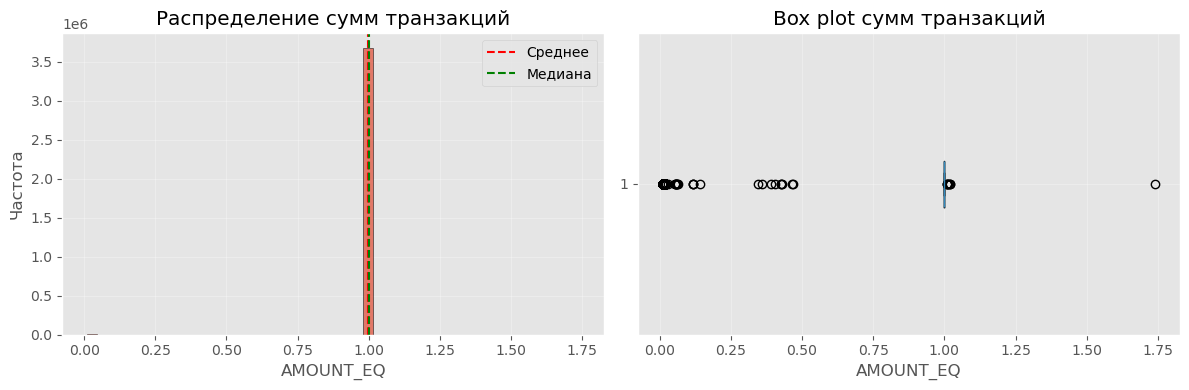

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew


amounts = data['EXCHANGE_RATA'].dropna()

print(f"Среднее: {amounts.mean():.2f}")
print(f"Медиана: {amounts.median():.2f}")
print(f"Мода: {amounts.mode().values[0]:.2f}")
print(f"Коэффициент асимметрии: {skew(amounts):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(amounts, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(amounts.mean(), color='red', linestyle='--', label='Среднее')
axes[0].axvline(amounts.median(), color='green', linestyle='--', label='Медиана')
axes[0].set_xlabel('AMOUNT_EQ')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение сумм транзакций')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(amounts, vert=False)
axes[1].set_xlabel('AMOUNT_EQ')
axes[1].set_title('Box plot сумм транзакций')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
data['CurrencyName'].unique()

array(['Рубль', 'Евро', 'Доллар США', 'Болгарский лев ', 'Чешская крона',
       'Украинская гривна', 'Злотый', 'Фунт стерлингов', 'Китайский юань',
       'Швейцарский франк', 'Шведская крона', 'Бразильский реал',
       'Канадский доллар', 'Иена'], dtype=object)

In [15]:
data[data['CurrencyName'] == 'Чешская крона']["EXCHANGE_RATA"]

1645122    0.426374
2129839    0.405812
2180558    0.390065
3038712    0.344299
3083257    0.360504
Name: EXCHANGE_RATA, dtype: float64

In [16]:
data['MCC'].nunique()
print(data['MCC'].nunique())

328


In [17]:
print("Минимальная дата:", data['DATE'].min())
print("Максимальная дата:", data['DATE'].max())
print("Пропущенные значения в DATE:", data['DATE'].isna().sum())

Минимальная дата: 2017-05-01 00:00:00
Максимальная дата: 2019-01-31 00:00:00
Пропущенные значения в DATE: 0


In [18]:
print("Уникальные клиенты:", data['ACCOUNT_ID'].nunique())
print("Транзакции на клиента:")
print(data['ACCOUNT_ID'].value_counts().describe())

Уникальные клиенты: 18640
Транзакции на клиента:
count    18640.000000
mean       198.030204
std        358.814256
min          3.000000
25%         17.000000
50%         75.000000
75%        280.000000
max      27820.000000
Name: count, dtype: float64


In [19]:
onehot_cols = ['PaymentSystem', 'OpType', 'DETAILEDCARDTYPE', 'TRANMETHOD', 'ISOWNTERMINAL', 'NAME', 'MCC', 'DEVICETYPE', 'CurrencyName', 'CITY', 'REGION', 'ISVIRTUALTRANSACTION']
cat_feat_names = ['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']
num_feat_names = ['AMOUNT_EQ', 'HOUR', 'MINUTE', 'SECOND', 'EXCHANGE_RATA']
log1p_transform_cols = ['AMOUNT_EQ', 'EXCHANGE_RATA']  # если суммы имеют skewed распределение
date_feature = 'DATE'
time_feature = 'TRANS_TIME'
client_id = 'ACCOUNT_ID'
mcc_name = 'MCC'
latent_dim = {'onehot': 128, 'categorical': 16, 'numerical': 4, 'cv': 32}

In [20]:
print("Размер исходных данных:", data.shape)
print("Уникальные клиенты:", data[client_id].nunique())
print("Пропуски в client_id:", data[client_id].isna().sum())
print("Пропуски в date_feature:", data[date_feature].isna().sum())

# Проверим распределение транзакций по клиентам
client_transactions = data[client_id].value_counts()
print("\nРаспределение транзакций по клиентам:")
print(client_transactions.describe())

# Сколько клиентов имеют достаточно транзакций
min_transactions = 2  # минимум для вычисления интервалов
enough_data_clients = client_transactions[client_transactions >= min_transactions]
print(f"Клиенты с ≥{min_transactions} транзакциями: {len(enough_data_clients)}")

# Дополнительная диагностика
print(f"\nДополнительная информация:")
print(f"Тип данных {date_feature}: {data[date_feature].dtype}")
print(f"Тип данных {client_id}: {data[client_id].dtype}")

# Проверим первые несколько значений
print(f"\nПервые 5 значений {date_feature}:")
print(data[date_feature].head())
print(f"\nПервые 5 значений {client_id}:")
print(data[client_id].head())

Размер исходных данных: (3691283, 36)
Уникальные клиенты: 18640
Пропуски в client_id: 0
Пропуски в date_feature: 0

Распределение транзакций по клиентам:
count    18640.000000
mean       198.030204
std        358.814256
min          3.000000
25%         17.000000
50%         75.000000
75%        280.000000
max      27820.000000
Name: count, dtype: float64
Клиенты с ≥2 транзакциями: 18640

Дополнительная информация:
Тип данных DATE: datetime64[ns]
Тип данных ACCOUNT_ID: object

Первые 5 значений DATE:
102275   2017-05-01
110434   2017-05-01
110473   2017-05-01
115262   2017-05-01
125000   2017-05-01
Name: DATE, dtype: datetime64[ns]

Первые 5 значений ACCOUNT_ID:
102275    7807339
110434    6751581
110473    5324659
115262    1427713
125000    4679655
Name: ACCOUNT_ID, dtype: object


In [21]:
import time

start_time = time.time()

In [22]:

X_emb, X_oh, cond_vector, synth_date, scaler_cat, scaler_onehot, scaler_num, cv_params, scaler, round_array = \
            trgan.embeddings(data, cat_feat_names, num_feat_names, onehot_cols, date_feature, time_feature, client_id, latent_dim, device=DEVICE, load=False, epochs=40, directory='Pretrains_model_sber/Pretrains_ALL/')


Loss E_num: 1.2149157555541024e-05: 100%|██████████| 40/40 [22:37<00:00, 33.93s/it]


Optimizing poisson intensity...


Loss E_cv: 0.000209226: 100%|██████████| 20/20 [11:49<00:00, 35.47s/it]


In [23]:
coding_time = time.time()

In [24]:

dim_noise = 20
generator, supervisor, loss_array = trgan.train(X_emb, cond_vector, latent_dim, dim_noise, epochs=40, load=False, experiment_id='sber', DIRECTORY='Pretrains_model_sber/Pretrains_ALL/')

Discriminator Loss: -0.05023 || Discriminator 2 Loss: -0.00011 || Generator Loss: 0.01204 || Supervisor Loss: 0.00424: 100%|██████████| 40/40 [51:34<00:00, 77.36s/it]


In [25]:
train_time = time.time()

In [26]:
n_samples = len(X_emb[:]) 
print(n_samples)
synth_data, synth_date, params = sample(n_samples, generator, supervisor, dim_noise, cond_vector, X_emb, cv_params['encoder'], data,\
                                date_feature, client_id, cv_params=cv_params, device=DEVICE)



X_emb1 = scaler.inverse_transform(X_emb)
synth_data = scaler.inverse_transform(synth_data)
print(synth_data)
synth_df = inverse_transform(synth_data, latent_dim, X_oh.columns, scaler_onehot, scaler_cat, scaler_num, cat_feat_names,
                             mcc_name, num_feat_names, True, synth_date, time_feature, round_array, device=DEVICE)


3691283
[[-0.7994422   0.79836553  0.8464001  ... -0.09206928 -0.6688993
  -0.6266723 ]
 [-0.8667494  -0.55884075  0.7249462  ... -0.09427026 -0.6937054
  -0.6496346 ]
 [-0.94590163  0.06585516  0.76583576 ... -0.09920736 -0.7152462
  -0.65800697]
 ...
 [-0.8744657  -0.59138614  0.94725376 ...  0.3616714   0.7881172
   0.63516676]
 [-0.8748874  -0.5908636   0.9473072  ...  0.36149395  0.78799546
   0.6353921 ]
 [-0.80918545  0.562736    0.81566143 ...  0.3677047   0.7945315
   0.6429109 ]]


In [27]:
sample_time = time.time()

In [28]:
synth_df['CurrencyName'].unique()

array(['Рубль', 'Доллар США', 'Евро', 'Болгарский лев ',
       'Бразильский реал', 'Фунт стерлингов'], dtype=object)

In [29]:
print(n_samples)

3691283


In [30]:
synth_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3691283 entries, 0 to 3691282
Data columns (total 20 columns):
 #   Column                Dtype         
---  ------                -----         
 0   PaymentSystem         object        
 1   OpType                object        
 2   DETAILEDCARDTYPE      object        
 3   TRANMETHOD            object        
 4   ISOWNTERMINAL         object        
 5   NAME                  object        
 6   MCC                   object        
 7   DEVICETYPE            object        
 8   CurrencyName          object        
 9   CITY                  object        
 10  REGION                object        
 11  ISVIRTUALTRANSACTION  object        
 12  ACCOUNT_ID            object        
 13  TERMINAL_CODE         object        
 14  CARD                  object        
 15  TRANS_DETAIL          object        
 16  AMOUNT_EQ             float64       
 17  EXCHANGE_RATA         float32       
 18  DATE                  datetime64[ns]
 19  

In [31]:
print(X_oh.columns)

Index(['PaymentSystem_MasterCard', 'PaymentSystem_Union Pay International',
       'PaymentSystem_VISA International', 'PaymentSystem_БАНК',
       'PaymentSystem_МИР - НСПК', 'OpType_Внесение наличных',
       'OpType_Возврат', 'OpType_Оплата', 'OpType_Отмена операции',
       'OpType_Перевод',
       ...
       'CITY_Шлиссельбург', 'CITY_Шушары', 'REGION_UNKNOWN', 'REGION_VIRTUAL',
       'REGION_Санкт-Петербург', 'REGION_обл Калининградская',
       'REGION_обл Ленинградская', 'REGION_обл Новгородская',
       'ISVIRTUALTRANSACTION_0', 'ISVIRTUALTRANSACTION_1'],
      dtype='object', length=578)


In [32]:
synth_df.to_csv('Data/synth_sber.csv', 
          index=False,           # Не записывать индексы
          sep=',',               # Разделитель
          encoding='utf-8',      # Кодировка
          header=True,           # Записывать заголовки
          na_rep='NULL')         # Замена NaN значений

In [33]:
# for i in range(latent_dim['onehot'],X_emb1.shape[1]):
#     plt.hist(X_emb1[:, i], bins=40, alpha=0.7, density=True)
#     plt.hist(synth_data[:, i], bins=40, alpha=0.7, density=True)

#     plt.show()

In [34]:
synth_df['DETAILEDCARDTYPE']

0          MasterCard Unembossed
1          MasterCard Unembossed
2          MasterCard Unembossed
3            MasterCard Standard
4          MasterCard Unembossed
                   ...          
3691278    MasterCard Unembossed
3691279    MasterCard Unembossed
3691280         MasterCard World
3691281    MasterCard Unembossed
3691282         MasterCard World
Name: DETAILEDCARDTYPE, Length: 3691283, dtype: object

In [35]:
cat_feat_names

['ACCOUNT_ID', 'TERMINAL_CODE', 'CARD', 'TRANS_DETAIL']

In [36]:

# plot_hist_categorical(data, synth_df, "CustomerKey", 100)

In [37]:
# plot_hist_categorical(data, synth_df, "ID", 5000)

In [38]:
# synth_df.head()

In [39]:
# synth_df["DEVICETYPE"].unique()

In [40]:
# data["DEVICETYPE"].unique()

In [41]:
# plot_hist_onehot(data, synth_df, "DEVICETYPE")
# plt.hist(data["ADDRESS"], alpha=0.6, label='Real', bins=np.arange(0, data["ADDRESS"].value_counts().shape[0], 10), color='black', rwidth=0.8, density=True)

In [42]:
# plot_hist_categorical(data, synth_df, "ADDRESS", 100)


In [43]:
# plot_hist_categorical(data, synth_df, "TERMINAL_CODE", 5000)

In [44]:
# plot_hist_categorical(data, synth_df, "TRANS_DETAIL", 500)

In [45]:
# plot_hist_categorical(data, synth_df, "ACCOUNT_ID", 50)

In [46]:
# plot_hist_categorical(data, synth_df, "CARD", 50)

In [47]:
num_feat_names

['AMOUNT_EQ', 'HOUR', 'MINUTE', 'SECOND', 'EXCHANGE_RATA']

In [48]:
# plot_hist_numerical(data, synth_df, 'AMOUNT_EQ', tick=100)

In [49]:
# evaluate_numerical([data['AMOUNT_EQ'], synth_df['AMOUNT_EQ']], ['Real', 'TRGAN'])

In [50]:
onehot_cols

['PaymentSystem', 'OpType', 'DETAILED_CARD_TYPE', 'TRAN_METHOD', 'ISOWNTERMINAL', 'NAME', 'MCC']

['PaymentSystem',
 'OpType',
 'DETAILED_CARD_TYPE',
 'TRAN_METHOD',
 'ISOWNTERMINAL',
 'NAME',
 'MCC']

In [51]:
# plot_hist_onehot(data, synth_df, 'MCC')

In [52]:
# plot_hist_onehot(data, synth_df, 'NAME')

In [53]:
# plot_hist_onehot(data, synth_df, 'ISOWNTERMINAL')

In [54]:
# synth_df['TRANMETHOD'].unique()

In [55]:
# plot_hist_onehot(data, synth_df, 'TRANMETHOD')

In [56]:
# plot_hist_onehot(data, synth_df, 'DETAILEDCARDTYPE')

In [57]:
# plot_hist_onehot(data, synth_df, 'OpType')

In [58]:
# plot_hist_onehot(data, synth_df, 'PaymentSystem')

In [59]:
coding_time_final = coding_time - start_time
print(coding_time)

1768697036.0042484


In [60]:
coding_time_seconds = coding_time - start_time  # предполагается, что это число секунд (float или int)

minutes, seconds = divmod(int(coding_time_seconds), 60)
hours, minutes = divmod(minutes, 60)

print(f"{hours:02d}:{minutes:02d}:{seconds:02d}")

01:54:11


In [61]:
train_time_seconds = train_time - coding_time  # предполагается, что это число секунд (float или int)

minutes, seconds = divmod(int(train_time_seconds), 60)
hours, minutes = divmod(minutes, 60)

print(f"{hours:02d}:{minutes:02d}:{seconds:02d}")

00:51:35


In [62]:
generate_time_seconds = sample_time - train_time  # предполагается, что это число секунд (float или int)

minutes, seconds = divmod(int(generate_time_seconds), 60)
hours, minutes = divmod(minutes, 60)

print(f"{hours:02d}:{minutes:02d}:{seconds:02d}")

00:06:31


In [63]:
full_time_seconds = sample_time - start_time  # предполагается, что это число секунд (float или int)

minutes, seconds = divmod(int(full_time_seconds), 60)
hours, minutes = divmod(minutes, 60)

print(f"{hours:02d}:{minutes:02d}:{seconds:02d}")

02:52:18
